<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 5: Imputación de datos</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_5_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:#2F749F;"><strong>Ejercicio 1. Limpieza e imputación de un conjunto de datos mixto</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
        'Edad': [25, np.nan, 35, 29, -5, 25, None],
        'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
        'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
        'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
    })

2. En un nuevo notebook, aplica las etapas del proceso de limpieza e imputación de datos que consideres necesarias sobre el DataFrame df. Ten encuenta incluir:
    - Código correctamente comentado y ejecutado.
    - Explicaciones breves de cada paso.
    - Resultados visuales o estadísticos que evidencien las transformaciones.

### **Solución:**

1.

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame(
    {
    'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
    'Edad': [25, np.nan, 35, 29, -5, 25, None],
    'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
    'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
    'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
    }
)

In [ ]:
df.head()

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,Bogotá,3500.0,2023-01-01
1,Luis,NaN,Medellín,4800.0,2023-01-05
2,Pedro,35.0,None,NaN,None
3,None,29.0,Medellín,5200.0,2023-01-10
4,Marta,-5.0,Cali,5100.0,2023-01-12


**Detección de valores faltantes**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Nombre        6 non-null      object 
 1   Edad          5 non-null      float64
 2   Ciudad        6 non-null      object 
 3   Ingreso       5 non-null      float64
 4   FechaIngreso  5 non-null      object 
dtypes: float64(2), object(3)
memory usage: 412.0+ bytes


In [ ]:
df.isnull().sum()

,0
Nombre,1
Edad,2
Ciudad,1
Ingreso,2
FechaIngreso,2


**2.Eliminación de duplicados**
No se encuentran duplicados

In [ ]:
#?

**3.Corrección de errores tipográficos y de codificación**

In [ ]:
#Todo a minusculas
df["Ciudad"] = df["Ciudad"].str.lower()
df.head()

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,bogotá,3500.0,2023-01-01
1,Luis,NaN,medellín,4800.0,2023-01-05
2,Pedro,35.0,None,NaN,None
3,None,29.0,medellín,5200.0,2023-01-10
4,Marta,-5.0,cali,5100.0,2023-01-12


In [ ]:
#Quitar tildes

import unicodedata

def remove_accents(text):
    if isinstance(text, str):
        return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    return text

df['Ciudad'] = df['Ciudad'].apply(remove_accents)
df.head()

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,bogota,3500.0,2023-01-01
1,Luis,NaN,medellin,4800.0,2023-01-05
2,Pedro,35.0,None,NaN,None
3,None,29.0,medellin,5200.0,2023-01-10
4,Marta,-5.0,cali,5100.0,2023-01-12


In [ ]:
#Poner las edades en enteros?????

4.Imputacipon de valor faltantes a las caracteristicas

In [ ]:
#Imputar valor faltante en Ciudad con la moda
df["Ciudad"] = df["Ciudad"].fillna(df["Ciudad"].mode())
df.head()

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,bogota,3500.0,2023-01-01
1,Luis,NaN,medellin,4800.0,2023-01-05
2,Pedro,35.0,medellin,NaN,None
3,None,29.0,medellin,5200.0,2023-01-10
4,Marta,-5.0,cali,5100.0,2023-01-12


In [ ]:
#Imputar valor faltante en Ingreso usando la mediana por si hay algun tipo d sesgo
df["Ingreso"] = df["Ingreso"].fillna(df["Ingreso"].median())
df.head()

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,bogota,3500.0,2023-01-01
1,Luis,NaN,medellin,4800.0,2023-01-05
2,Pedro,35.0,medellin,4800.0,None
3,None,29.0,medellin,5200.0,2023-01-10
4,Marta,-5.0,cali,5100.0,2023-01-12


In [ ]:
#Imputar valor faltante en FechaIngreso usando moda
df["FechaIngreso"] = df["FechaIngreso"].fillna(df["FechaIngreso"].mode())
df.head()

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,bogota,3500.0,2023-01-01
1,Luis,NaN,medellin,4800.0,2023-01-05
2,Pedro,35.0,medellin,4800.0,2023-01-10
3,None,29.0,medellin,5200.0,2023-01-10
4,Marta,-5.0,cali,5100.0,2023-01-12


In [ ]:
#Manejo del valor negativo en edad y lo convierto a NaN
df.loc[df["Edad"] < 0, "Edad"] = np.nan
df.head()

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,bogota,3500.0,2023-01-01
1,Luis,NaN,medellin,4800.0,2023-01-05
2,Pedro,35.0,medellin,4800.0,2023-01-10
3,None,29.0,medellin,5200.0,2023-01-10
4,Marta,NaN,cali,5100.0,2023-01-12


In [ ]:
#Manejo de los NaN en Edad con mediana
df["Edad"] = df["Edad"].fillna(df["Edad"].median())
df.head()

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,bogota,3500.0,2023-01-01
1,Luis,27.0,medellin,4800.0,2023-01-05
2,Pedro,35.0,medellin,4800.0,2023-01-10
3,None,29.0,medellin,5200.0,2023-01-10
4,Marta,27.0,cali,5100.0,2023-01-12


## <span style="color:#2F749F;"><strong>Ejercicio 2. Limpieza de duplicados</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'ID': [101, 102, 102, 103, 104, 104, 104],
        'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
        'Edad': [25, 30, 30, 29, 40, 40, 41],
        'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
        'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                        '2023-01-15', '2023-01-15', '2023-01-16']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, responde a las siguientes preguntas (utilizando python):
    - ¿Cuál es el total de registros originales?
    - ¿Cuáles y cuántos son los duplicados exactos?
    - ¿Cuáles y cuántos son los duplicados por varias columnas?
    - ¿Cuántos registros debes eliminar?
    - ¿Cuántos registros quedan después de la limpieza?

### **Solución:**

1.

In [ ]:
import pandas as pd

df_1 = pd.DataFrame(
    {
    'ID': [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
    'Edad': [25, 30, 30, 29, 40, 40, 41],
    'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
    'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                    '2023-01-15', '2023-01-15', '2023-01-16']
    }
)

In [ ]:
df_1.head(7)

,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
3,103,Marta,29,Medellín,2023-01-10
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


2.

In [ ]:
#EL numero de registros originales
len(df_1)

7

In [ ]:
# que filas Filas son duplicadas
print(f"NUmero de duplicados (y que por ende vamos a eliminar porque no aportan nada): {df_1.duplicated().sum()}")

NUmero de duplicados (y que por ende vamos a eliminar porque no aportan nada): 2


In [ ]:
#Duplicados por columnas
caracteristicas = ["ID", "Nombre", "Edad", "Ciudad", "FechaRegistro"]

for x in caracteristicas:
    duplicado = df_1[x].duplicated().sum()
    print(f"Duplicados enn {x}: {duplicado}")

Duplicados enn ID: 3
Duplicados enn Nombre: 3
Duplicados enn Edad: 2
Duplicados enn Ciudad: 4
Duplicados enn FechaRegistro: 2


In [ ]:
"""
Elimino los que estan totalmente duplicados, no tengo el contexto suficiente para saber si
se permiten mas de 1 registro para la misma persona, por ende dejo quieto a Carlos
"""

df_1 = df_1.drop_duplicates()
print(df_1)

    ID  Nombre  Edad    Ciudad FechaRegistro
0  101     Ana    25    Bogotá    2023-01-01
1  102    Luis    30      Cali    2023-01-05
3  103   Marta    29  Medellín    2023-01-10
4  104  Carlos    40      Cali    2023-01-15
6  104  Carlos    41      Cali    2023-01-16


In [ ]:
#Tamaño nuevo del dataset
print(f"Nuevo tamaño del dataset: {len(df_1)}")

Nuevo tamaño del dataset: 5


## <span style="color:#2F749F;"><strong>Ejercicio 3. Corrección de errores tipográficos o de codificación</strong></span>


1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, estandariza la variable ciudad utilizando python.

### **Solución:**

**1.**

In [ ]:
df_2 = pd.DataFrame(
    {
    'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
    }
)

In [ ]:
df_2.head()

,Ciudad
0,bogota
1,Bogotá
2,BOGOTA
3,bogotá
4,bogata


2.

In [ ]:
#Todo a minusculas
df_2["Ciudad"] = df_2["Ciudad"].str.lower()
df_2.head()

,Ciudad
0,bogota
1,bogotá
2,bogota
3,bogotá
4,bogata


In [ ]:
#Quitar acentos
def remove_accents(text):
    if isinstance(text, str):
        return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    return text

df_2["Ciudad"] = df_2["Ciudad"].apply(remove_accents)
df_2.head()

,Ciudad
0,bogota
1,bogota
2,bogota
3,bogota
4,bogata


In [ ]:
#Quitar errores de escritura
df_2.loc[df_2["Ciudad"] == "bogata", "Ciudad"] = "bogota"
df_2.head()

,Ciudad
0,bogota
1,bogota
2,bogota
3,bogota
4,bogota


## <span style="color:#2F749F;"><strong>Ejercicio 4. Identificación de mecanismos de datos faltantes (MCAR, MAR, MNAR)</strong></span>
1. Se tiene una base de datos de estudiantes universitarios con las siguientes variables: , Edad, Género, Promedio académico, Ingreso familiar y Horas de estudio por semana. Sin embargo, hay valores faltantes en algunas variables.
2. En los siguientes escenarios, clasifica el tipo de dato faltante (MCAR, MAR o MNAR) y justifica tu respuesta en máximo 2 líneas.
   - **Escenario 1.**  Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).
   - **Escenario 2.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 3.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 4.** Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.
   - **Escenario 5.** Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.
   

## Base de Datos


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Introducción de valores faltantes con distintos patrones
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan


In [ ]:
df.head(10)

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56,2.70,35.0,2909818.0,7
1,46,2.27,NaN,3031785.0,7
2,32,NaN,30.0,5283302.0,9
3,25,3.15,14.0,NaN,3
4,38,4.95,7.0,3525928.0,7
5,56,NaN,13.0,4653339.0,1
6,36,4.58,22.0,NaN,4
7,40,4.04,NaN,1879111.0,4
8,28,NaN,20.0,1796107.0,5
9,28,2.04,15.0,4321441.0,7


### Clasifica el tipo de dato faltante (MCAR, MAR o MNAR) y justifica tu respuesta en máximo 2 líneas

**Escenario 1.**  Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).

*  MCAR:
Los datos NaN en la variable ingreso familiar aparecen de forma aleatoria, es decir, **no depende ni de las variables observadas ni de las no observadas**. Por lo tanto se utilizaN métodos como análisis de casos completos, imputación simple o múltiple.

**Escenario 2 y 3.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.

* MAR: Los datos NaN de la variable Horas de Estudio dependen de la variable promedio, por ende se pueden imputar con imputación múltiple (MICE), modelos de máxima verosimilitud, o EM (Expectation-Maximization).

**Escenario 4.** Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.
*  MAR: Se observa que la variable Promedio academico depende de la variable género, por ende el patrón de datos ausentes puede ser modelado a partir de la información disponible

**Escenario 5.** Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.
* MNAR: El valor faltante depende directamente de él mismo, es por ello que se hace un supuesto que los estudiantes no registran los datos porque es muy bajo para registrarlo.


## <span style="color:#2F749F;"><strong>Ejercicio 5. Imputación con KNN y regresión</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

    ```python
        import pandas as pd
        import numpy as np

        np.random.seed(42)

        n = 30

        df = pd.DataFrame({
            'Edad': np.random.randint(18, 60, n),
            'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
            'Horas_estudio': np.random.randint(0, 40, n),
            'Ingreso_familiar': np.random.randint(800000, 8000000, n),
            'Semestres_cursados': np.random.randint(1, 10, n)
        })

        # Introducción de valores faltantes con distintos patrones
        df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
        df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
        df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

2. Al analizar el dataframe `df`:
   - ¿Qué variables tienen mayor proporción de datos faltantes?
   - ¿Observas algún patrón estructurado o parecen aleatorios?

3. Realiza la imputación de valores faltantes utilizando KNN y regresión
4. Analiza si se preserva la naturaleza de los datos con cada una de las técnicas de imputación (KNN y regresión)

**1. Carga de Datos**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Introducción de valores faltantes con distintos patrones
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

**2. Análisis a DataFrame**

* Datos Faltantes: ¿Qué variables tienen mayor proporción de datos faltantes?

In [ ]:
valores_nulos = df.isnull().sum()
porcentaje_valores_nulos = (df.isnull().sum() / len(df)) * 100

tabla = pd.DataFrame({
    'Conteo': valores_nulos,
    'Porcentaje': porcentaje_valores_nulos
})

print("Número y porcentaje de valores nulos por columna:")
print(tabla)

Número y porcentaje de valores nulos por columna:
                    Conteo  Porcentaje
Edad                     0    0.000000
Promedio                 4   13.333333
Horas_estudio            4   13.333333
Ingreso_familiar         3   10.000000
Semestres_cursados       0    0.000000


La variable Promedio y Horas_estudio tienen la mayor proporcion de valores faktantes, con un 13.33%

* ¿Observas algún patrón estructurado o parecen aleatorios?

In [ ]:
def scatter_missing(df, x, y):
    plt.figure(figsize=(8,5))

    mask = df[y].isnull()

    plt.scatter(df.loc[~mask, x], df.loc[~mask, y], label="Observado", alpha=0.7)
    plt.scatter(df.loc[mask, x], [0]*mask.sum(),
                marker='x', s=100, label="Missing")

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"Datos con valores faltantes, {y} respecto a {x}")
    plt.legend()
    plt.grid()
    plt.show()



**Se ouede observar un pequeño patrón  de los valores faltantes en Horas_estudio respecto a Edad, ya que estos valores están agrupados entre 40 y 47 años.**

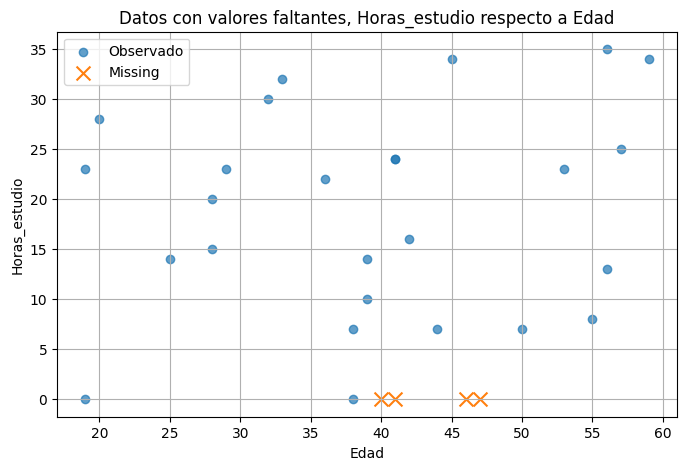

In [ ]:
scatter_missing(df, "Edad", "Horas_estudio")

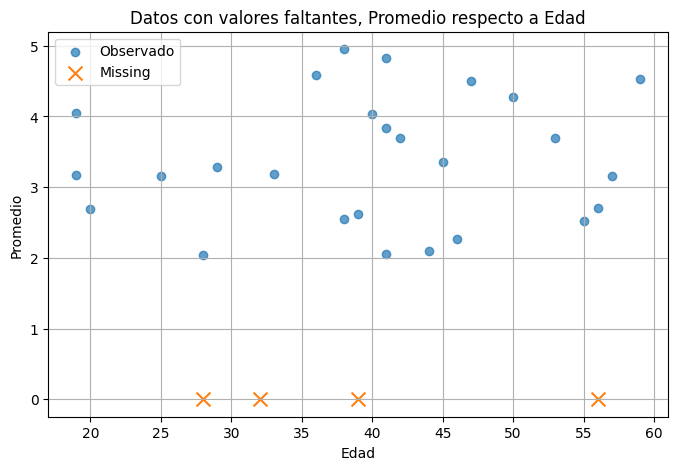

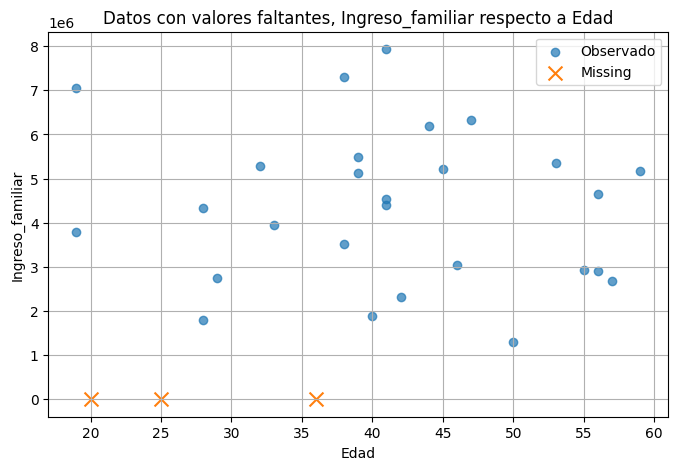

In [ ]:
scatter_missing(df, "Edad", "Promedio")
scatter_missing(df, "Edad", "Ingreso_familiar")

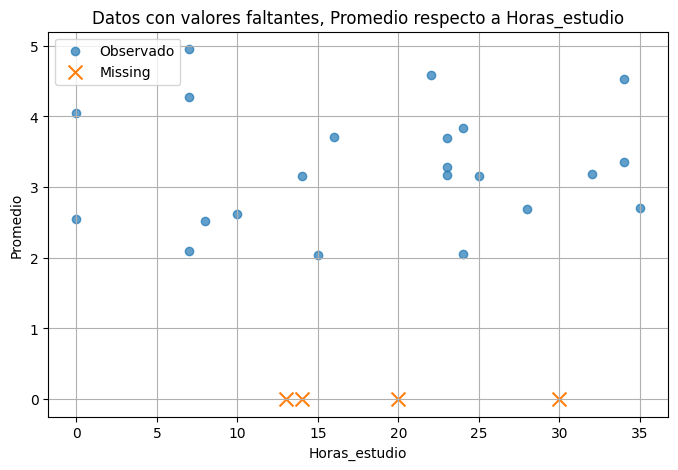

In [ ]:
scatter_missing(df, "Horas_estudio", "Promedio")

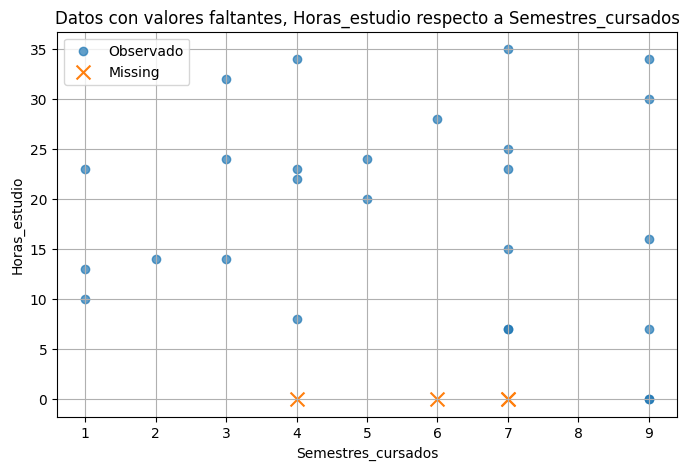

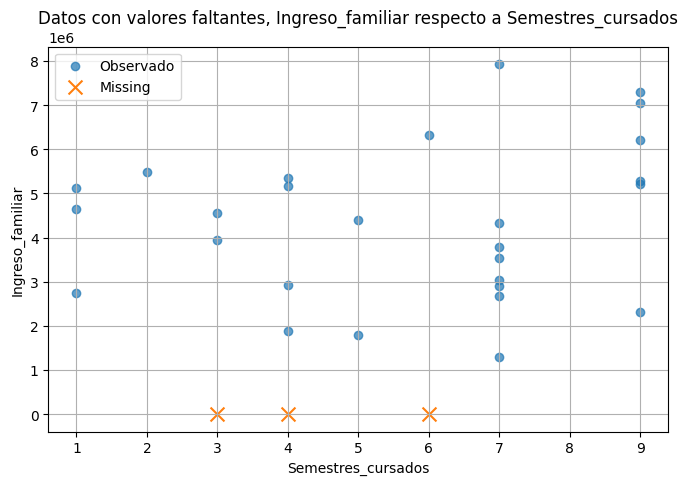

In [ ]:
scatter_missing(df, "Semestres_cursados", "Horas_estudio")
scatter_missing(df, "Semestres_cursados", "Ingreso_familiar")

**Los valores faltantes  en las graficas no muestran patrones evidentes.**

3. Realiza la imputación de valores faltantes utilizando **KNN y regresión**


**KNN**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import pandas as pd

def grafico_imputacion_KNN(df, col_x, col_y, k=3):
    # Copia con missing
    data_missing = df[[col_x, col_y]].copy()

    # Imputación
    imputer = KNNImputer(n_neighbors=k)
    data_imputed = pd.DataFrame(
        imputer.fit_transform(data_missing),
        columns=[col_x, col_y]
    )

    # Máscara de missing
    mask_missing = data_missing[col_y].isnull()

    # -------- Gráfico 1: datos con missing --------
    plt.figure(figsize=(8,6))
    plt.scatter(data_missing[col_x], data_missing[col_y],
                color="gray", alpha=0.7, label="Datos disponibles")

    plt.scatter(data_missing.loc[mask_missing, col_x],
                [0]*mask_missing.sum(),
                marker="x", color="black", s=100,
                label="Valores faltantes")

    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.title(f"{col_y} con valores faltantes")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------- Gráfico 2: imputación --------
    plt.figure(figsize=(8,6))
    plt.scatter(data_imputed.loc[~mask_missing, col_x],
                data_imputed.loc[~mask_missing, col_y],
                color="gray", alpha=0.7, label="Original")

    plt.scatter(data_imputed.loc[mask_missing, col_x],
                data_imputed.loc[mask_missing, col_y],
                color="lightcoral", edgecolors="black",
                linewidths=1.2, s=100,
                label="Imputado")

    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.title(f"Imputación KNN de {col_y} (K={k})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Verificación
    print("\nAntes:")
    print(data_missing.isnull().sum())
    print("\nDespués:")
    print(data_imputed.isnull().sum())

    return data_missing, data_imputed, mask_missing


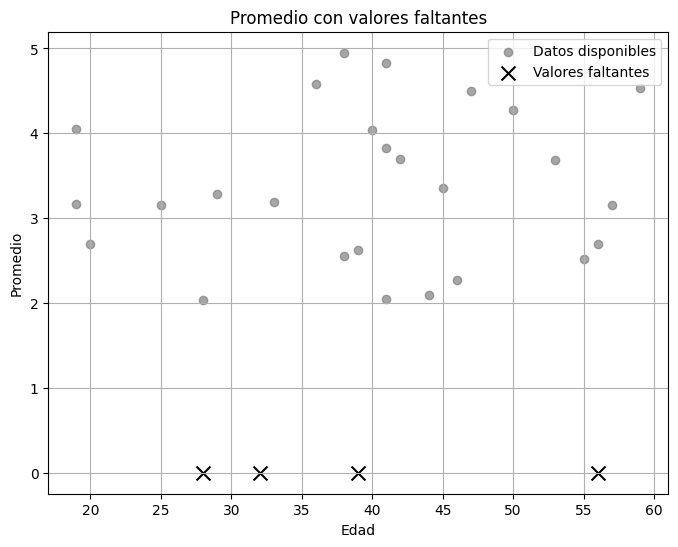

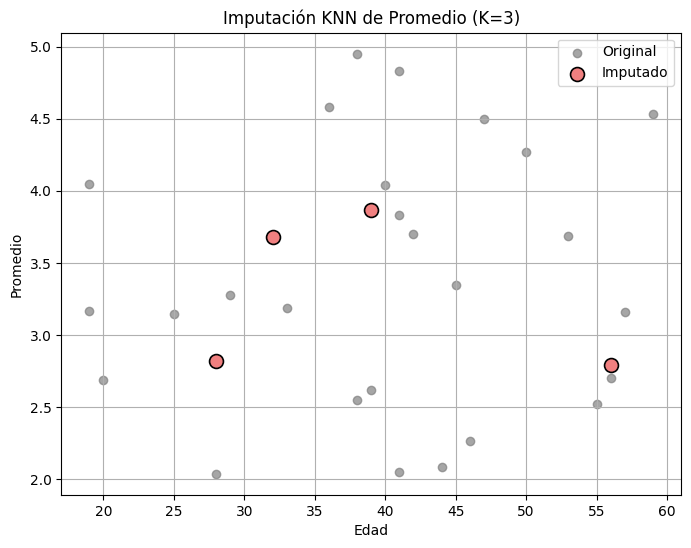


Antes:
Edad        0
Promedio    4
dtype: int64

Después:
Edad        0
Promedio    0
dtype: int64


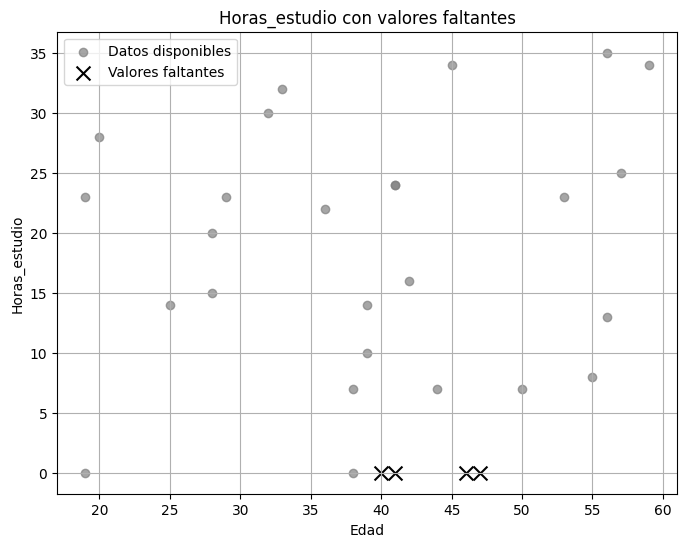

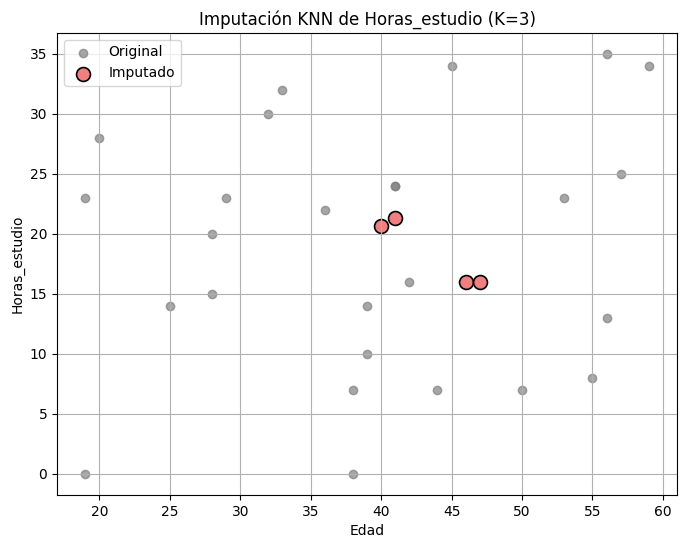


Antes:
Edad             0
Horas_estudio    4
dtype: int64

Después:
Edad             0
Horas_estudio    0
dtype: int64


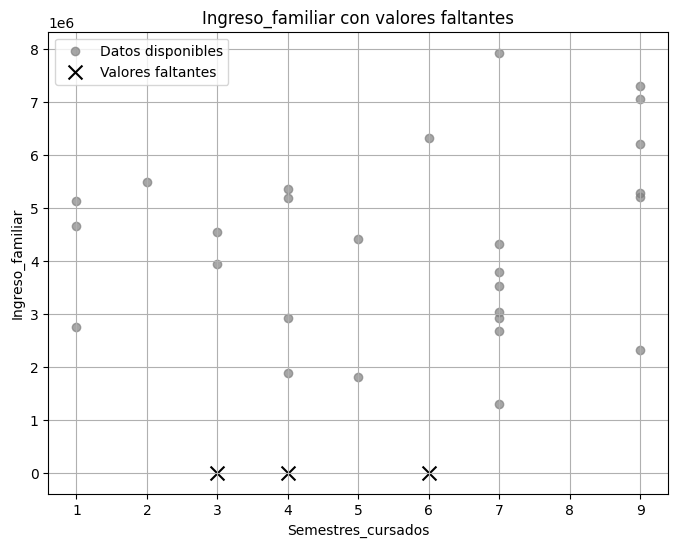

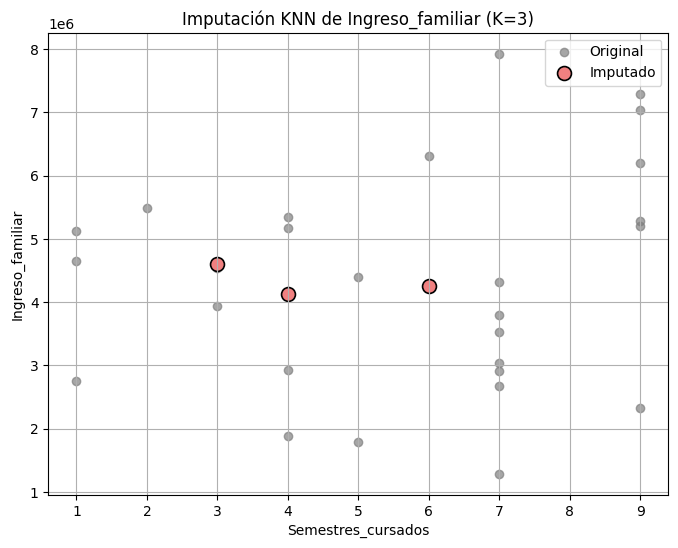


Antes:
Semestres_cursados    0
Ingreso_familiar      3
dtype: int64

Después:
Semestres_cursados    0
Ingreso_familiar      0
dtype: int64


In [ ]:
orig1, imputadoKNN1, mask1 = grafico_imputacion_KNN(df, "Edad", "Promedio")
orig2, imputadoKNN2, mask2 = grafico_imputacion_KNN(df, "Edad", "Horas_estudio")
orig3, imputadoKNN3, mask3 = grafico_imputacion_KNN(df, "Semestres_cursados", "Ingreso_familiar")

**Regresión**

In [ ]:
from sklearn.linear_model import LinearRegression

def grafico_imputacion_regresion(df, col_x, col_y):

    # Copia del dataset
    data_missing = df[[col_x, col_y]].copy()

    # Máscara de valores faltantes
    mask_missing = data_missing[col_y].isnull()

    # Separar datos
    X_train = data_missing.loc[~mask_missing, [col_x]]
    y_train = data_missing.loc[~mask_missing, col_y]
    X_missing = data_missing.loc[mask_missing, [col_x]]

    # Modelo de regresión
    reg = LinearRegression()
    reg.fit(X_train, y_train)

    # Imputación
    data_imputed = data_missing.copy()
    if len(X_missing) > 0:
        data_imputed.loc[mask_missing, col_y] = reg.predict(X_missing)

    # -------- Gráfico 1: datos con missing --------
    plt.figure(figsize=(8,6))

    plt.scatter(data_missing[col_x], data_missing[col_y],
                alpha=0.7, label="Datos disponibles")

    # Ubicar missing fuera del rango real (NO en 0)
    y_fake = data_missing[col_y].min() - 0.5

    plt.scatter(data_missing.loc[mask_missing, col_x],
                [y_fake]*mask_missing.sum(),
                marker="x", s=100, label="Missing")

    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.title(f"{col_y} con valores faltantes")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------- Gráfico 2: imputación --------
    plt.figure(figsize=(8,6))

    plt.scatter(data_imputed.loc[~mask_missing, col_x],
                data_imputed.loc[~mask_missing, col_y],
                alpha=0.7, label="Original")

    plt.scatter(data_imputed.loc[mask_missing, col_x],
                data_imputed.loc[mask_missing, col_y],
                edgecolors="black", linewidths=1.2,
                s=100, label="Imputado (regresión)")

    # Línea de regresión
    x_line = np.linspace(df[col_x].min(), df[col_x].max(), 100).reshape(-1,1)
    y_line = reg.predict(x_line)

    plt.plot(x_line, y_line, linestyle="--", label="Regresión")

    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.title(f"Imputación por regresión de {col_y}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------- Verificación --------
    print("\nValores faltantes antes:")
    print(data_missing.isnull().sum())

    print("\nValores faltantes después:")
    print(data_imputed.isnull().sum())

    return data_missing, data_imputed, mask_missing


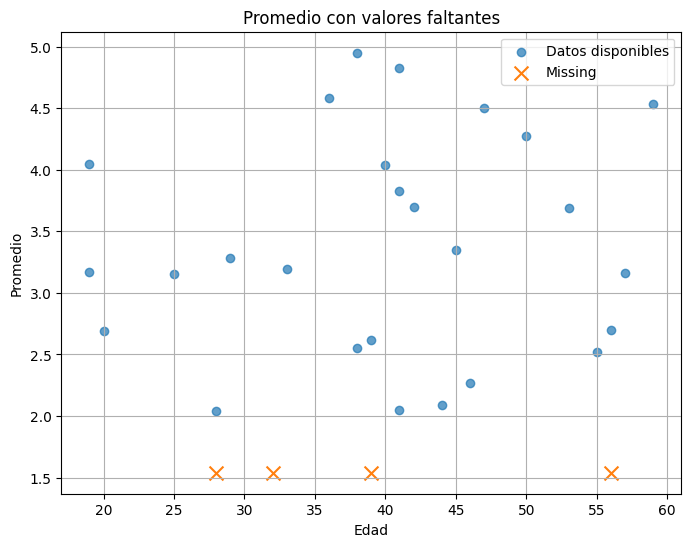

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


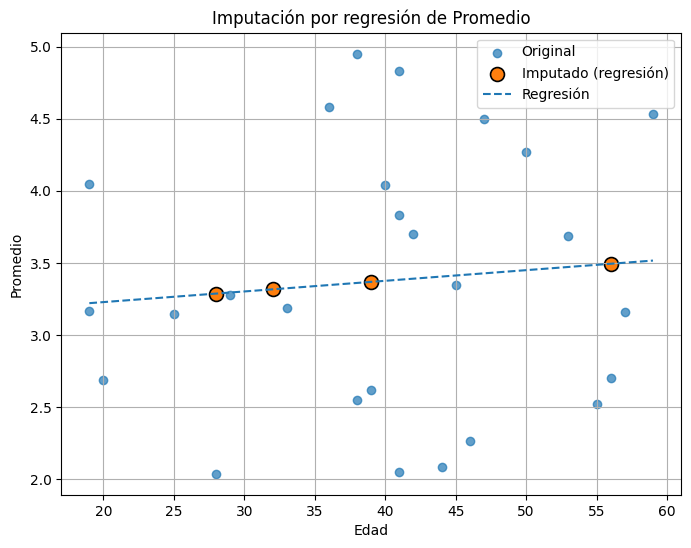


Valores faltantes antes:
Edad        0
Promedio    4
dtype: int64

Valores faltantes después:
Edad        0
Promedio    0
dtype: int64


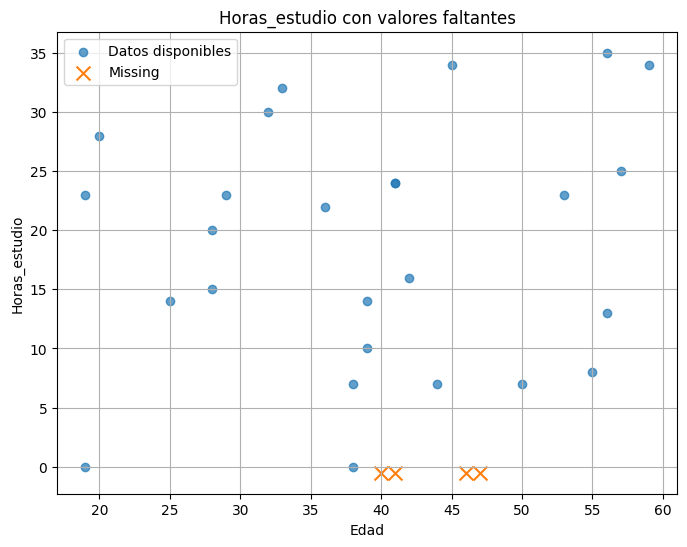

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


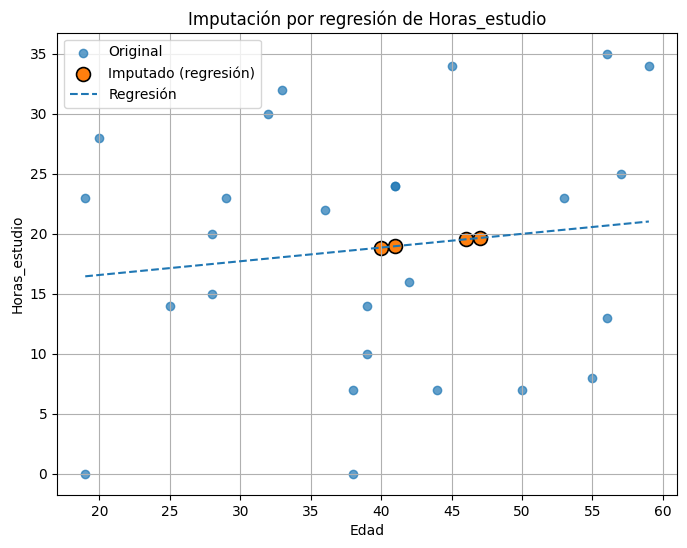


Valores faltantes antes:
Edad             0
Horas_estudio    4
dtype: int64

Valores faltantes después:
Edad             0
Horas_estudio    0
dtype: int64


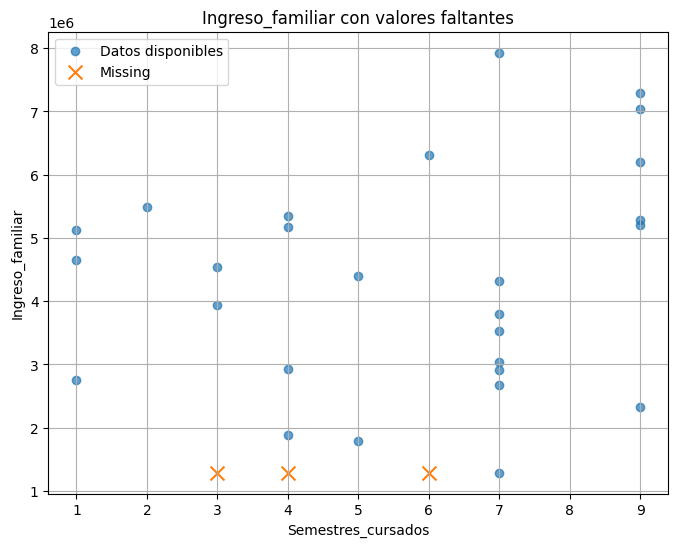

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


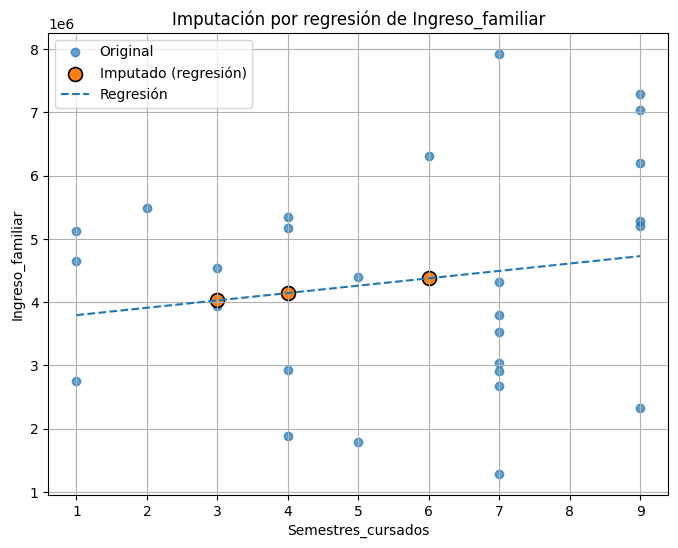


Valores faltantes antes:
Semestres_cursados    0
Ingreso_familiar      3
dtype: int64

Valores faltantes después:
Semestres_cursados    0
Ingreso_familiar      0
dtype: int64


In [ ]:
orig, imputado_reg_1, mask_reg_1  = grafico_imputacion_regresion(df, "Edad", "Promedio")
orig, imputado_reg_2, mask_reg_2  = grafico_imputacion_regresion(df, "Edad", "Horas_estudio")
orig, imputado_reg_3, mask_reg_3  = grafico_imputacion_regresion(df, "Semestres_cursados", "Ingreso_familiar")

4. Analiza si se preserva la naturaleza de los datos con cada una de las técnicas de imputación (KNN y regresión)

**Distribuciones**

In [ ]:
import matplotlib.pyplot as plt

def comparar_distribuciones(orig, knn, reg, col_y, titulo=""):

    plt.figure(figsize=(8,5))

    # Original
    plt.hist(orig[col_y].dropna(), bins=10, density=True,
             histtype='step', linewidth=2, label="Original")

    # KNN
    plt.hist(knn[col_y], bins=10, density=True,
             histtype='step', linewidth=2, linestyle='--', label="KNN")

    # Regresión
    plt.hist(reg[col_y], bins=10, density=True,
             histtype='step', linewidth=2, linestyle=':', label="Regresión")

    plt.title(f"Distribución de {col_y} {titulo}")
    plt.xlabel(col_y)
    plt.ylabel("Densidad")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

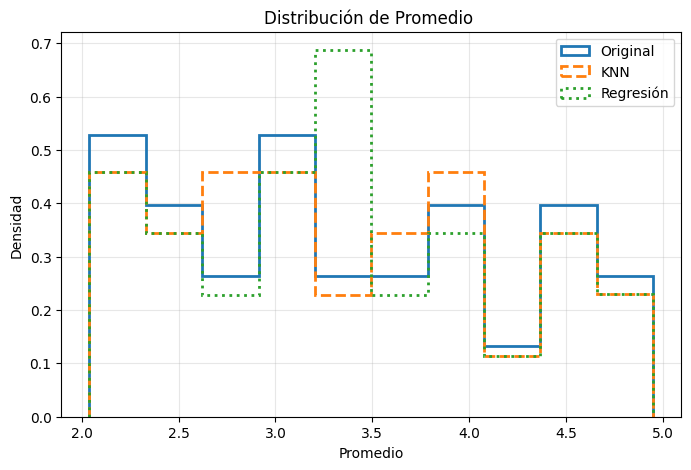

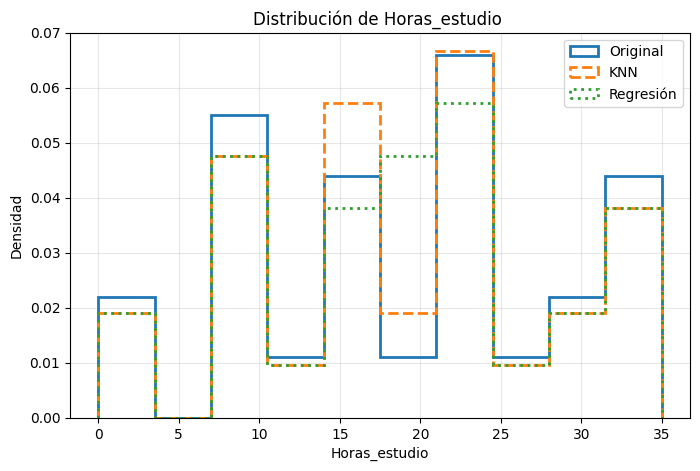

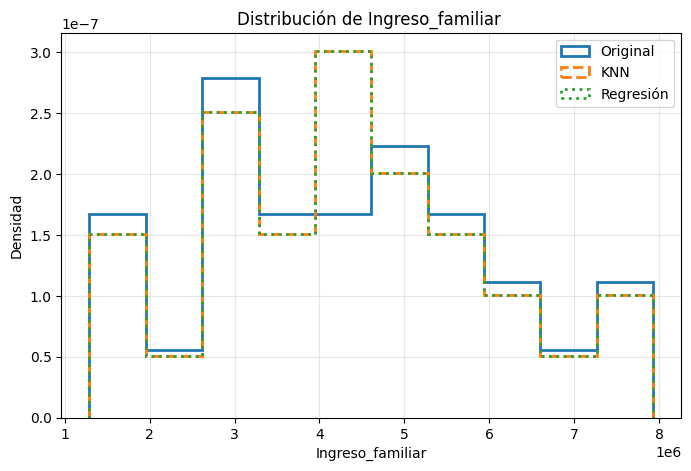

In [ ]:
comparar_distribuciones(orig1, imputadoKNN1, imputado_reg_1, "Promedio")
comparar_distribuciones(orig2, imputadoKNN2, imputado_reg_2, "Horas_estudio")
comparar_distribuciones(orig3, imputadoKNN3, imputado_reg_3, "Ingreso_familiar")

**Estadisticos**

In [ ]:
def diferencias(orig, knn, reg, col):

    print(f"\n Diferencias en {col}")

    print("\nMedia:")
    print("KNN - Original:", knn[col].mean() - orig[col].mean())
    print("Reg - Original:", reg[col].mean() - orig[col].mean())

    print("\nDesviación estándar:")
    print("KNN - Original:", knn[col].std() - orig[col].std())
    print("Reg - Original:", reg[col].std() - orig[col].std())

    print("\nMediana:")
    print("KNN - Original:", knn[col].median() - orig[col].median())
    print("Reg - Original:", reg[col].median() - orig[col].median())



In [ ]:
diferencias(orig1, imputadoKNN1, imputado_reg_1, "Promedio")


 Diferencias en Promedio

Media:
KNN - Original: -0.011256410256409666
Reg - Original: -0.0012671516843254516

Desviación estándar:
KNN - Original: -0.04440405628133415
Reg - Original: -0.06386470863751437

Mediana:
KNN - Original: 0.0
Reg - Original: 0.06787981059269432


**Para la variable promedio, KNN preserva mejor la variabilidad y la estructura central de los datos.**

In [ ]:
diferencias(orig2, imputadoKNN2, imputado_reg_2, "Horas_estudio")


 Diferencias en Horas_estudio

Media:
KNN - Original: -0.03589743589743577
Reg - Original: 0.06385064044638611

Desviación estándar:
KNN - Original: -0.6959243678306297
Reg - Original: -0.7391587884763879

Mediana:
KNN - Original: -0.6666666666666643
Reg - Original: -1.4092047975026674


**Para la variable Horas_estudio, tambien KNN preserva mejor la naturaleza de los datos, pues mantiene mas estable la media. Diferente a la Regresion que intricuce mayor distorción**

In [ ]:
diferencias(orig3, imputadoKNN3, imputado_reg_3, "Ingreso_familiar")


 Diferencias en Ingreso_familiar

Media:
KNN - Original: -789.037037037313
Reg - Original: -15536.112066905014

Desviación estándar:
KNN - Original: -91841.62744227727
Reg - Original: -91785.14578372776

Mediana:
KNN - Original: -40419.0
Reg - Original: -52387.730286737904


**Para la varible Ingreso_familiar, KNN preserva mejor la naturaleza de los datos, ya que mantiene más estable la media y altera en menor medida la mediana. La regresión introduce un sesgo fuerte, desplazando significativamente la distribución.**

## <span style="color:#2F749F;"><strong>Ejercicio 6. Imputación con LOCF y NOCB</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

    ```python
        import pandas as pd
        import numpy as np

        np.random.seed(42)

        n = 30

        df = pd.DataFrame({
            'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
            'Ventas': np.round(np.random.uniform(100, 500, n), 2),
            'Inventario': np.random.randint(10, 100, n),
            'Clientes': np.random.randint(1, 50, n)
        })

        # Introducción de valores faltantes
        df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
        df.loc[[7, 8, 20], 'Inventario'] = np.nan
        df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
        df = df.sort_values('Fecha').reset_index(drop=True)

2. Al analizar el DataFrame `df`:
   - ¿Qué variables presentan datos faltantes consecutivos?
   - ¿Por qué este tipo de patrón es relevante en series temporales?
   - ¿Qué implicaciones tiene el orden de los datos para este tipo de imputación?
3. Realiza la imputación de valores faltantes utilizando LOCF y NOCB
4. ¿Cuál método consideras más apropiado para este caso y por qué?

**Solución:**

In [ ]:
#1 Crear el dataframe
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
    'Ventas': np.round(np.random.uniform(100, 500, n), 2),
    'Inventario': np.random.randint(10, 100, n),
    'Clientes': np.random.randint(1, 50, n)
})

# Introducción de valores faltantes
df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
df.loc[[7, 8, 20], 'Inventario'] = np.nan
df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan

df = df.sort_values('Fecha').reset_index(drop=True)

df

,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.0,29.0
1,2023-01-02,480.29,16.0,NaN
2,2023-01-03,392.80,30.0,NaN
3,2023-01-04,NaN,82.0,44.0
4,2023-01-05,NaN,48.0,34.0
5,2023-01-06,NaN,27.0,10.0
6,2023-01-07,123.23,13.0,36.0
7,2023-01-08,446.47,NaN,14.0
8,2023-01-09,340.45,NaN,31.0
9,2023-01-10,383.23,23.0,48.0


In [ ]:
#2 Identificar valores faltantes
df.isnull().sum()

,0
Fecha,0
Ventas,5
Inventario,3
Clientes,4


In [ ]:
#3 Detectar valores faltantes consecutivos
print("Ventas con NaN consecutivos en índices:", [3,4,5,12,13])
print("Inventario con NaN consecutivos en índices:", [7,8])
print("Clientes con NaN consecutivos en índices:", [1,2,18,19])

Ventas con NaN consecutivos en índices: [3, 4, 5, 12, 13]
Inventario con NaN consecutivos en índices: [7, 8]
Clientes con NaN consecutivos en índices: [1, 2, 18, 19]


**Interpretación:**
1. Variables con datos faltantes consecutivos:
- Ventas (3-5, 12-13)
- Inventario (7-8)
- Clientes (1-2, 18-19)

2. Relevancia en series temporales:
Los valores consecutivos faltantes afectan la continuidad de la información, lo que puede distorsionar tendencias y patrones en el tiempo.

3. Implicación del orden:
El orden es clave porque métodos como LOCF y NOCB dependen de valores
anteriores o posteriores. Si el DataFrame no está ordenado por fecha,
la imputación sería incorrecta.

In [ ]:
#4 Imputación con LOCF (Forward Fill)

df_locf = df.fillna(method='ffill')

df_locf

/tmp/ipykernel_12319/936038938.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_locf = df.fillna(method='ffill')


,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.0,29.0
1,2023-01-02,480.29,16.0,29.0
2,2023-01-03,392.80,30.0,29.0
3,2023-01-04,392.80,82.0,44.0
4,2023-01-05,392.80,48.0,34.0
5,2023-01-06,392.80,27.0,10.0
6,2023-01-07,123.23,13.0,36.0
7,2023-01-08,446.47,13.0,14.0
8,2023-01-09,340.45,13.0,31.0
9,2023-01-10,383.23,23.0,48.0


In [ ]:
#5 Imputación con NOCB (Backward Fill)
df_nocb = df.fillna(method='bfill')

df_nocb

/tmp/ipykernel_12319/1469076746.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_nocb = df.fillna(method='bfill')


,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.0,29.0
1,2023-01-02,480.29,16.0,44.0
2,2023-01-03,392.80,30.0,44.0
3,2023-01-04,123.23,82.0,44.0
4,2023-01-05,123.23,48.0,34.0
5,2023-01-06,123.23,27.0,10.0
6,2023-01-07,123.23,13.0,36.0
7,2023-01-08,446.47,23.0,14.0
8,2023-01-09,340.45,23.0,31.0
9,2023-01-10,383.23,23.0,48.0


**Comparación y conclusión:**

LOCF (Last Observation Carried Forward):
- Usa el último valor conocido
- Mantiene continuidad temporal
- Más realista en datos como ventas o inventario

NOCB (Next Observation Carried Backward):
- Usa valores futuros
- Puede introducir información que no existía en ese momento

Conclusión:
LOCF es más apropiado en este caso porque respeta la lógica temporal
(no usa información del futuro).